In [1]:
from sklearn.feature_extraction.text import CountVectorizer
import glob
import pandas as pd
import nltk
from nltk import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk import pos_tag

In [2]:
# modeli za ustrezno obdelavo stavkov, besed, ločil....
nltk.download('punkt')     # stavki, besede
nltk.download('wordnet') #lemmatizacija
nltk.download('averaged_perceptron_tagger') #POS tagganje
nltk.download('omw-1.4') 
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mokro\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mokro\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\mokro\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\mokro\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\mokro\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\mokro\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_percep

True

In [3]:
# tokenization and lemmatization 
lemmatizer= WordNetLemmatizer()

In [4]:
# pokupčkamo besede s podobnim korenom, pomenom skupaj
# run, runs, running -> run
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('RB'):
        return wordnet.ADV
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    else:
        return wordnet.NOUN

In [5]:
def tokenize_lematize(tekst):
    tokens = word_tokenize(tekst.lower())  # vse besede pišemo z malo začetnico
    tagged = pos_tag(tokens)
    return [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in tagged
        if word.isalpha()    # znebimo se ločil, st,...
    ]

In [6]:
# CountVectorizer odstrani 'stopwords' in ustvari nenegativno matriko, na (i, j)-tem mestu
# imamo pojavitev besede i v j-tem dokumentu (glej zapiske na tablici)


# vzamemo 49/50 knjig, eno bomo potem poskusali uvrstiti med žanre
filepaths = glob.glob(r'C:\Users\mokro\Desktop\diploma\dipl_data\knjige_opisi\*.txt')
# min_df=2, max_df=0.9 odstranita redke in pogoste besede, to uniči celoten rezultat
vectorizer= CountVectorizer(stop_words='english', 
                            tokenizer= tokenize_lematize,
                            input = 'filename', 
                            encoding='latin-1', 
                            min_df=2, 
                            max_df=0.9)

In [7]:
X = vectorizer.fit_transform(filepaths) 


c:\Users\mokro\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\mokro\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['far', 'make', 'u'] not in stop_words.
  warnings.warn(


In [8]:
print(X)

# malo lepše, prikaz
dense_matrix = X.toarray()
print(dense_matrix)

#še lepše
feature_names = vectorizer.get_feature_names_out()
df = pd.DataFrame(dense_matrix, columns=feature_names)
print(df.head())

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1692 stored elements and shape (49, 504)>
  Coords	Values
  (0, 269)	1
  (0, 355)	1
  (0, 478)	2
  (0, 163)	2
  (0, 44)	2
  (0, 481)	1
  (0, 439)	1
  (0, 321)	1
  (0, 494)	1
  (0, 127)	1
  (0, 172)	1
  (0, 69)	1
  (0, 119)	1
  (0, 293)	1
  (0, 415)	1
  (0, 267)	1
  (0, 296)	1
  (0, 344)	1
  (0, 262)	1
  (0, 7)	1
  (0, 496)	1
  (0, 376)	1
  (0, 412)	1
  (0, 331)	1
  (0, 218)	1
  :	:
  (48, 226)	1
  (48, 386)	1
  (48, 402)	1
  (48, 324)	2
  (48, 369)	1
  (48, 259)	1
  (48, 309)	1
  (48, 105)	1
  (48, 217)	1
  (48, 104)	1
  (48, 197)	1
  (48, 395)	1
  (48, 316)	1
  (48, 30)	2
  (48, 205)	1
  (48, 120)	1
  (48, 81)	1
  (48, 471)	1
  (48, 178)	2
  (48, 364)	1
  (48, 115)	1
  (48, 243)	1
  (48, 129)	1
  (48, 28)	1
  (48, 396)	1
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 1 0]
 ...
 [1 0 0 ... 0 0 0]
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 0 0]]
   acclaim  achieve  achievement  act  action  adult  adventure  affair  \
0        0   

In [9]:
from sklearn.decomposition import PCA

In [40]:
pca = PCA(n_components=5)  
X_pca = pca.fit_transform(X)

In [41]:
print(pca.explained_variance_ratio_)
print("Skupaj:", sum(pca.explained_variance_ratio_))

[0.12897067 0.05839901 0.04952806 0.04726925 0.04113105]
Skupaj: 0.32529804005433793


In [42]:
feature_names = vectorizer.get_feature_names_out()

for i, comp in enumerate(pca.components_):
    top_words = [feature_names[j] for j in comp.argsort()[-10:]]
    print(f"PC{i+1}: {top_words}")

PC1: ['world', 'death', 'dark', 'series', 'wizard', 'lord', 'potter', 'voldemort', 'hogwarts', 'harry']
PC2: ['mean', 'rebellion', 'death', 'win', 'everdeen', 'hunger', 'district', 'capitol', 'game', 'katniss']
PC3: ['harry', 'age', 'lose', 'hobbit', 'rule', 'dark', 'baggins', 'bilbo', 'lord', 'ring']
PC4: ['friendship', 'rule', 'world', 'life', 'book', 'love', 'time', 'dark', 'power', 'ring']
PC5: ['world', 'library', 'novel', 'katniss', 'lord', 'just', 'voldemort', 'american', 'war', 'time']


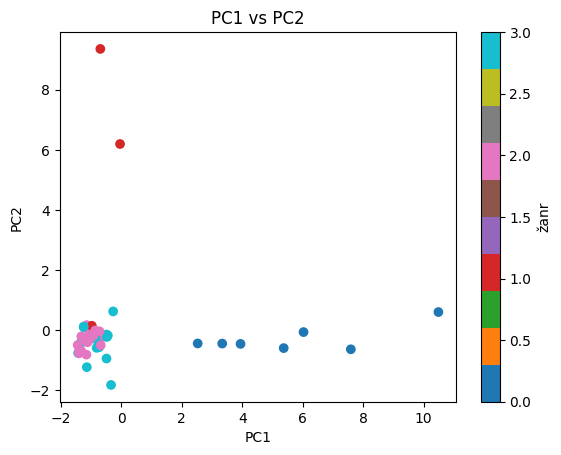

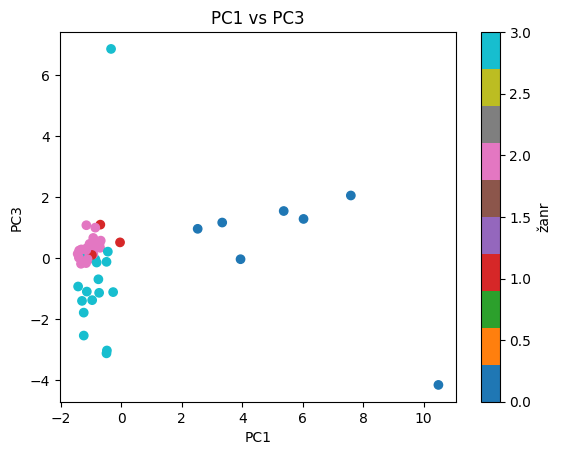

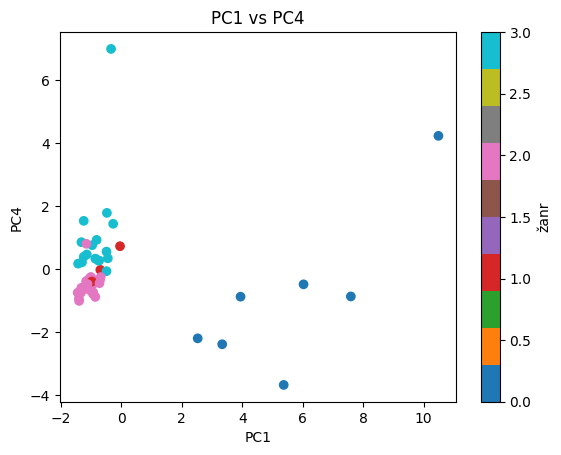

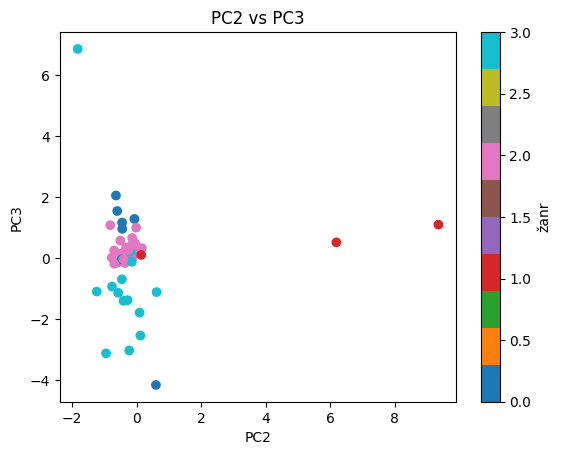

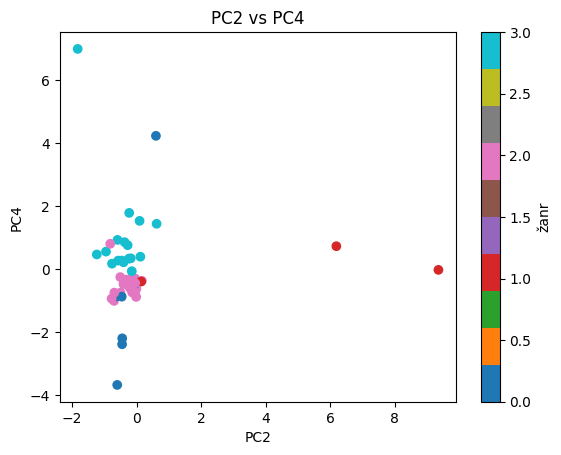

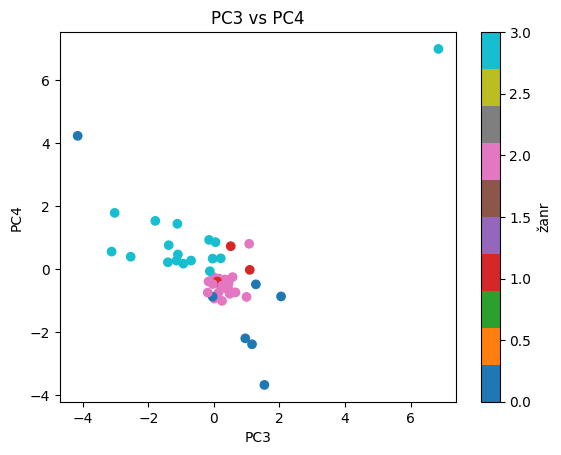

In [36]:
import matplotlib.pyplot as plt
labels = X_pca.argmax(axis=1)   

pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]

for i, j in pairs:
    plt.figure()
    plt.scatter(
        X_pca[:, i],
        X_pca[:, j],
        c=labels,       
        cmap="tab10"    
    )
    plt.xlabel(f"PC{i+1}")
    plt.ylabel(f"PC{j+1}")
    plt.title(f"PC{i+1} vs PC{j+1}")
    plt.colorbar(label="žanr")   
    plt.show()

plt.show()